Fingerprinting

This workbook uses a IDL_python bridge to run fingerprinting analysis on seasonal runoff data across New Zealand. It defines functions which read previously created runoff datafiles and setup the data_obs, data_scen, and noise vectors. These vectors are then input into Daithi Stone's gendetec IDL code which returns the regression coefficients for the multiple linear regression problem as follows: data_obs = beta_est * data_scen + residual. 

Results are saved in ~/figures/fingerprinting/beta_est/ if using a single truncation and ""/scan_beta_est/ if depicting a range of truncation options. 

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
from functools import reduce
import matplotlib.pyplot as plt
from idlpy import *
from scipy import stats
import statsmodels.api as sm


import seaborn as sns
import cartopy.crs as ccrs

IDL 8.7.2 (linux x86_64 m64).
(c) 2019, Harris Geospatial Solutions, Inc.

Licensed for use by: NIWA - National Institute of Water and Atmospheric Research Ltd - Ashley
License: 229483-BUF
Expiration date: 31-Mar-2023
A new version is available: IDL 8.8.3
https://harrisgeospatial.flexnetoperations.com
 


In [4]:
df = pd.read_csv('/nesi/project/niwa00015/queenle/data/runoff/winter_obs.csv')
df = df.set_index('date')

In [5]:
df

,-35.550846 174.0,-37.04772 174.75,-37.04772 175.5,-37.79616 175.5,-37.79616 177.75,-38.5446 174.75,-38.5446 175.5,-38.5446 176.25,-38.5446 177.0,-38.5446 177.75,...,-44.532104 169.5,-44.532104 171.0,-45.28054 168.0,-45.28054 168.75,-45.28054 170.25,-46.028976 167.25,-46.028976 168.0,-46.028976 168.75,-46.028976 169.5,-46.028976 170.25
date,,,,,,,,,,,,,,,,,,,,,
1979-06-01,112627.645342,1632.430370,40015.076087,76615.521739,221587.923913,14548.608696,46465.239130,33277.717391,65948.782609,63727.217391,...,63491.521739,236.717391,251258.815217,27826.347826,1793.858696,11436.130435,7327.510870,5310.934783,27505.880435,794.271739
1980-06-01,76973.576087,606.697554,17108.836957,51686.445652,254248.728261,16219.913043,45330.217391,9858.880435,48761.641304,68370.461509,...,110123.489130,472.510870,387098.380435,94391.500000,7463.065217,21203.717391,14792.890110,18888.771739,73490.672337,2200.478261
1981-06-01,71644.043478,722.882011,14927.021739,50036.187469,155231.445652,0.000000,77689.978261,38258.228261,104681.988636,66828.608696,...,82459.804348,402.391304,184367.043478,37836.760870,4322.641304,9613.532609,6546.815217,8900.250000,34756.533413,2115.630435
1982-06-01,39322.260870,318.055348,9998.239130,33381.858696,122016.021739,9612.902174,36747.271739,7273.054348,38873.750000,25157.391304,...,78153.706522,86.054348,246824.402174,32686.456522,0.000000,13485.880435,0.000000,9677.706522,36252.747348,0.000000
1983-06-01,46265.793478,390.933348,9134.271739,34622.065217,231562.076087,9668.858696,41792.489130,17591.532609,51317.858696,33044.880435,...,111798.195652,344.989130,324544.108696,73712.510870,3735.173913,15278.445652,14143.054348,12171.521739,49374.374272,0.000000
1984-06-01,44720.230099,565.740847,8940.847826,37493.097826,291167.032609,0.000000,54597.032609,25028.967391,55461.967391,60985.684783,...,91045.010870,202.478261,298968.322634,59499.695652,2462.054348,12200.260870,5932.348315,9222.760870,41526.177185,705.815217
1985-06-01,58770.663043,427.456522,20805.467391,54660.663043,222632.903197,15929.163043,49057.391304,22880.673913,92758.108696,43133.639752,...,96557.152174,198.206522,255367.184783,28554.565217,1345.739130,11707.097826,5056.195652,5385.423913,20271.379391,0.000000
1986-06-01,46039.894277,541.633837,13912.760870,38764.315217,143868.445652,23332.494505,71227.032609,27108.423913,60963.413043,39347.739130,...,105040.119565,0.000000,340492.869565,65262.853893,5328.543478,17924.521739,10678.206522,12798.065217,51411.119793,1137.144444
1987-06-01,41035.675935,320.104196,15919.684783,34292.068216,127672.684783,11407.804348,37059.989130,23525.967391,48451.695652,58248.793478,...,101324.108696,284.532609,352204.380435,62005.637376,3231.217391,17306.054348,10768.241379,11280.108696,48245.586957,764.511111


In [2]:
cell_list = [
       '-35.5508 174.0', '-37.0477 174.75', '-37.0477 175.5',
       '-37.7961 175.5', '-37.7961 177.75', '-38.5446 174.75',
       '-38.5446 175.5', '-38.5446 176.25', '-38.5446 177.0',
       '-38.5446 177.75', '-39.2930 174.0', '-39.2930 174.75',
       '-39.2930 175.5', '-39.2930 176.25', '-40.0414 176.25',
       '-40.7899 172.5', '-40.7899 175.5', '-40.7899 176.25',
       '-41.5383 172.5', '-41.5383 173.25', '-41.5383 174.0',
       '-42.2867 171.75', '-42.2867 172.5', '-42.2867 173.25',
       '-43.0352 171.0', '-43.0352 172.5', '-43.7836 169.5',
       '-43.7836 170.25', '-43.7836 171.0', '-43.7836 171.75',
       '-44.5321 168.75', '-44.5321 169.5', '-44.5321 171.0',
       '-45.2805 168.0', '-45.2805 168.75', '-45.2805 170.25',
       '-46.0289 167.25', '-46.0289 168.0', '-46.0289 168.75',
       '-46.0289 169.5', '-46.0289 170.25']

In [3]:
file_name = 'mrro_Lmon-ANZ_ECHAM5-4_All-Hist_est1_v1-0_ens01_197901-201902.nc'
file_path = '../stoneda/data-for-laura/C20C/NOAA-ESRLandCIRES/ECHAM5-4/All-Hist/est1/v1-0/mon/land-ANZ/mrro/ens01/' + file_name

example_member = xr.open_dataset(file_path)
example_member = example_member['mrro'].sel(time=slice('1979-03-01','2019-03-01')).resample(time='QS-DEC').mean()
example_da = example_member.sel(time=example_member.time.dt.month.isin([3]))

example_stacked = example_da.stack(grid_cell=('lat','lon'))

mask_array = np.zeros(example_stacked.shape)

for i,cell in enumerate(example_stacked.indexes['grid_cell']):
    
    coords = str(cell[0])[:8] + " " + str(cell[1])
        
    if coords in cell_list:
        mask_val = 1
    else:
        mask_val = 0
    for k in range(len(example_da.time.values)):
        mask_array[k][i] = mask_val
        
mask_array.shape

(40, 598)

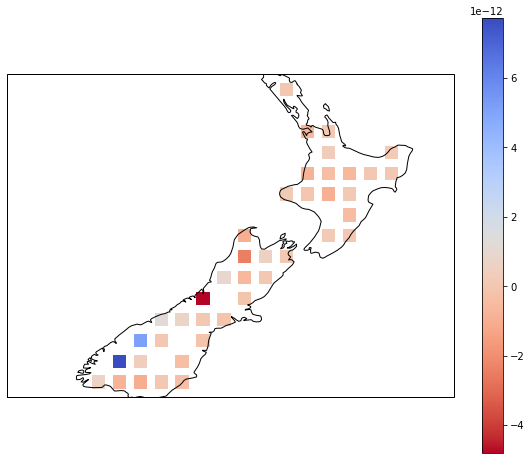

In [4]:
file_name = 'mrro_Lmon-ANZ_ECHAM5-4_All-Hist_est1_v1-0_ens01_197901-201902.nc'
file_path = '../stoneda/data-for-laura/C20C/NOAA-ESRLandCIRES/ECHAM5-4/All-Hist/est1/v1-0/mon/land-ANZ/mrro/ens01/' + file_name

ens_mem = xr.open_dataset(file_path)

# grab time window, resample to seasonal
ens_mem = ens_mem['mrro'].sel(time=slice('1979-03-01','2019-03-01')).resample(time='QS-DEC').mean()
# select season
season_da = ens_mem.sel(time=ens_mem.time.dt.month.isin([3]))
# stack lat, lon
season_da = season_da.stack(grid_cell=('lat','lon'))
# add mask coordinate
season_da.coords['mask'] = (('time','grid_cell'),mask_array)
# mask runoff to only cells with observed records
season_da = season_da.where(season_da.mask == 1,drop=True)

# take log of entire data array
#log_da = np.log(season_da)

# subtract temporal mean from each cell
mean_removed = season_da - season_da.mean(dim='time')

plt.figure(figsize=(10,8))
ax=plt.axes(projection=ccrs.PlateCarree())

im = ax.scatter([cell[1] for cell in mean_removed.indexes['grid_cell']],[cell[0] for cell in mean_removed.indexes['grid_cell']],c=mean_removed.mean('time').values,cmap='coolwarm_r',marker='s',s=150)

ax.coastlines(resolution='50m', color='black', linewidth=1)
ax.set_xlim([164,180])

plt.colorbar(im)

plt.show()

#log_mean_removed.values.shape


In [24]:
'''
A function which reads season_obs.csv and creates a seasonal data_obs vector. 
season: a string in ['fall','winter','spring','summer']
'''

def get_obs_data(scen, season):
    
    df = pd.read_csv('data/runoff/' + season + '_obs.csv')
    df = df.set_index('date')
    #df = df.mask(df==0).fillna(df.mean())
    
    
    # take log only
    #df = np.log10(df)

    # subtract mean only
    #df = df - df.mean()
    
    # take log, subtract mean
    #df = np.log10(df)
    #df = df - df.mean()
    
    # divide by mean and subtract 1
    df = df / df.mean()
    df = df - 1
    
    
    data_array = np.reshape(df.values,40*41)
    #print(df.columns)
    
    return(data_array)

In [25]:
'''
A function which calculates the noise array of a specific scenario. The array has 50x41 dimensions because there
are 50 ensemble members and 41 grid cells. Each ensemble member has its own noise vector. 

season: a string in ['fall','winter','spring','summer']
scen: a string in ['all','nat'] 
typ: a string in ['annual','decadal','trend'] which determines the temporal scale of the return vector. If 'trend'
     is chosen, the kendall-tau tau value is recorded for each cell.
scen_data: the respective (all or nat) data_scen vector which is the average of ensemble members in the appropriate
           unit (annual, decadal, trend seasonal runoff)
'''

def get_mean_and_noise(season,scen,typ):
    
    if scen == 'all':
        path = '../stoneda/data-for-laura/C20C/NOAA-ESRLandCIRES/ECHAM5-4/All-Hist/est1/v1-0/mon/land-ANZ/mrro/ens'
        file_name_setup = ['mrro_Lmon-ANZ_ECHAM5-4_All-Hist_est1_v1-0_ens','_197901-201902.nc']
    if scen == 'nat':
        path = '../stoneda/data-for-laura/C20C/NOAA-ESRLandCIRES/ECHAM5-4/Nat-Hist/obs-trend-1880s-est1/v1-0/mon/land-ANZ/mrro/ens'
        file_name_setup = ['mrro_Lmon-ANZ_ECHAM5-4_Nat-Hist_obs-trend-1880s-est1_v1-0_ens','_197901-201912.nc']
        
    ens_members = []
    
    for ens_mem in range(1,51):
        number = '0' + str(ens_mem) if ens_mem < 10 else str(ens_mem)
        file_name = file_name_setup[0]+number+file_name_setup[1]
        file_path = path + number + "/" + file_name

        ens_mem = xr.open_dataset(file_path)
        
        # grab time window, resample to seasonal
        ens_mem = ens_mem['mrro'].sel(time=slice('1979-03-01','2019-03-01')).resample(time='QS-DEC').mean()
        # select season
        season_da = ens_mem.sel(time=ens_mem.time.dt.month.isin([season]))
        # stack lat, lon
        season_da = season_da.stack(grid_cell=('lat','lon'))
        # add mask coordinate
        season_da.coords['mask'] = (('time','grid_cell'),mask_array)
        # mask runoff to only cells with observed records
        season_da = season_da.where(season_da.mask == 1,drop=True)
        
        da = season_da
        
        # take log only
        #da = np.log10(season_da)
        
        # remove local mean only
        #da = season_da - season_da.mean(dim='time')
        
        # take log, subtract mean
        #da = np.log10(season_da)
        #da = da - da.mean(dim='time')
        
        # divide by mean and subtract 1
        #local_means = da.mean(dim='time').sel({"grid_cell":( -39.29303741455078, 174.75)})
        #print(da.indexes["grid_cell"])
        #print(local_means)
        #print(da.sel({"grid_cell":( -39.29303741455078, 174.75)}))
        da = da / da.mean(dim='time')
        #print(da.sel({"grid_cell":( -39.29303741455078, 174.75)}))
        da = da - 1
        
        # values shape 40,41: (time,space)
        data_array = da.values.reshape(40*41)
                        
        ens_members.append(data_array)
        
    ens_mean = np.mean(np.array(ens_members),axis=0)
    
    #print(ens_mean.shape)
            
    noise = []
    for i,member in enumerate(ens_members):
        difference = np.subtract(member,ens_mean)
        noise.append(difference)
        
    
    #print(np.array(noise).shape)
    
    return([np.array(ens_mean), np.array(noise), np.array(ens_members)])



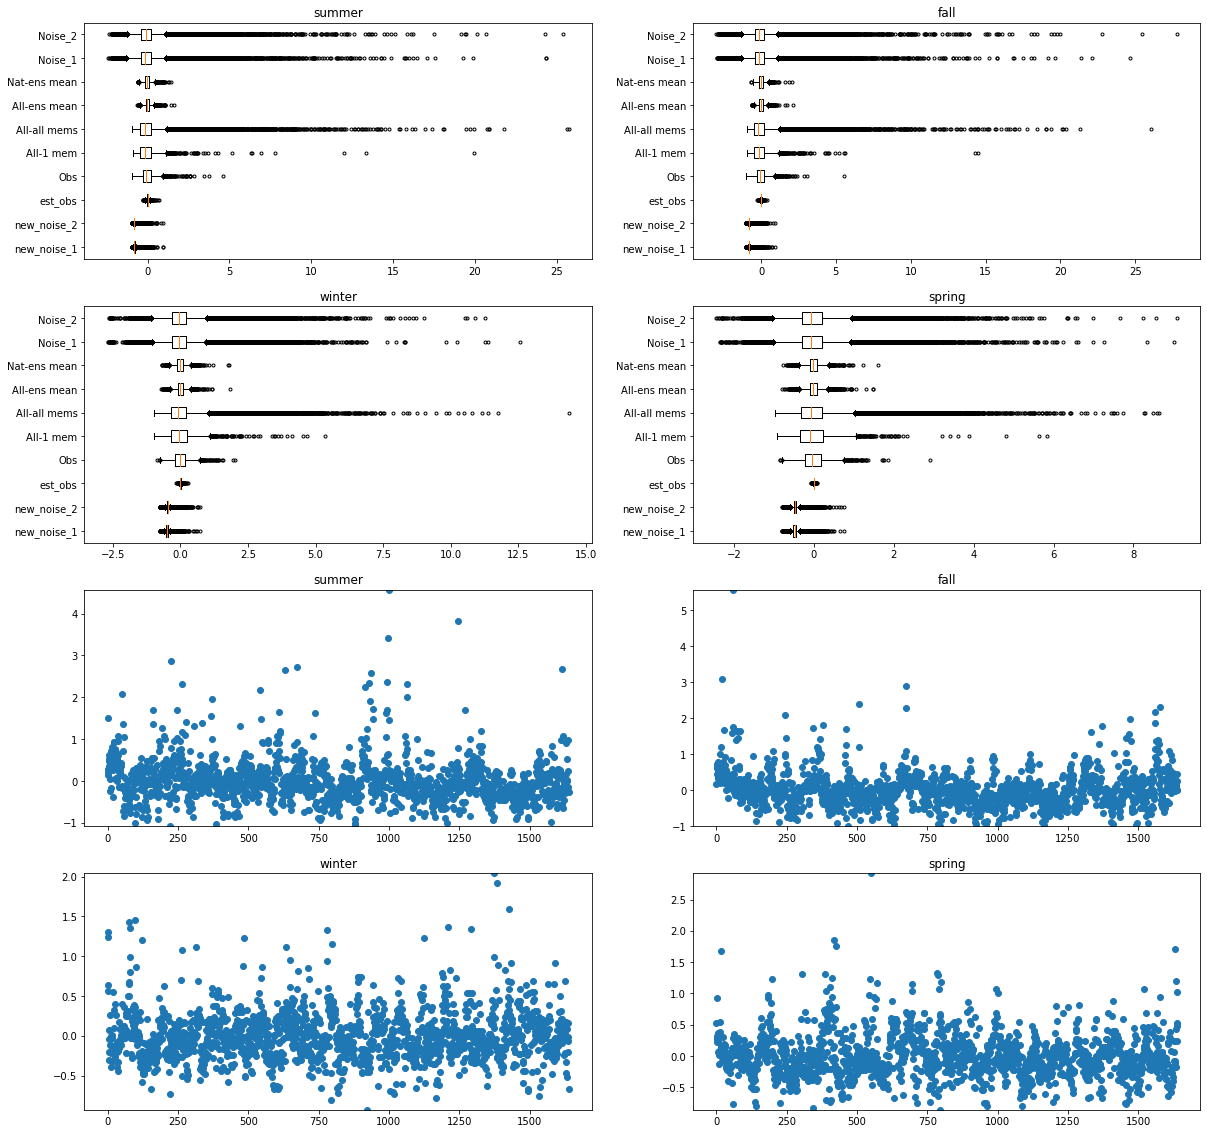

In [26]:
'''
MAIN PROGRAM

Create a seasonal plot of the regression coefficients using an array of trunctions.
The plots are saved in ~/figures/fingerprinting/scan_beta_est.
'''

fig,axs = plt.subplots(4,2, figsize=(20,20),squeeze=True)#, sharex=True,sharey=True)

axs = axs.flatten()

season_residuals = []
season_est_obs = []
season_obs = []

seasons = ['summer','fall','winter','spring']
for i in range(4):
    
    season = seasons[i]
        
    season_n = {'fall':3,'winter':6,'spring':9,'summer':12}[season]
    IDL.retall
    
    data_obs = get_obs_data('obs',season)
    
    all_ens_mean,noise_all,all_ens = get_mean_and_noise(season_n,'all','annual')
    nat_ens_mean,noise_nat,nat_ens = get_mean_and_noise(season_n,'nat','annual')
    
    data_noise_1 = np.concatenate((noise_all[:25],noise_nat[:25]))
    data_noise_2 = np.concatenate((noise_all[25:],noise_nat[25:]))
    
    data_scen = np.array([all_ens_mean,nat_ens_mean])
    
    trunc = np.array([i for i in range(3,48)])
    #trunc = 25

    B = axs[i].boxplot(data_obs)
    
    #a = min(data_obs)
    #b = max(data_obs)
    
    a=B['whiskers'][0].get_ydata()[1]
    b=B['whiskers'][1].get_ydata()[1]
    
    axs[i].clear()
    
    def scale(ary):
        mn = min(ary.flatten())
        mx = max(ary.flatten())
        
        new_ary = np.zeros(ary.shape)
        for i in range(ary.shape[0]):
            for j in range(ary.shape[1]):
                val = ary[i][j]
                new_ary[i][j] = (((b-a)*(val-mn))/(mx-mn))+a
                    
        return new_ary
        
    new_noise_1 = scale(data_noise_1)
    new_noise_2 = scale(data_noise_2)    
    
    IDL.data_obs = data_obs
    IDL.data_scen = data_scen
    IDL.data_noise_1 = new_noise_1
    IDL.data_noise_2 = new_noise_2
    IDL.trunc = trunc
    IDL.scan_beta_est = []
    IDL.scan_p_resid = []
    IDL.scan_resid_sumsq = []
    IDL.p_resid = []
    IDL.resid_sumsq = []
    IDL.noise_singval = []
    IDL.z_best = []

    IDL.run("gendetec, data_obs, data_scen, data_noise_1, beta_est, scan_resid_sumsq=scan_resid_sumsq, \
            data_noise_2=data_noise_2,transform=['1*0','1*0+1*1'], trunc=trunc, scan_beta_est=scan_beta_est,\
            scan_p_resid=scan_p_resid,noise_singval=noise_singval,z_best=z_best")

    #IDL.run("gendetec, data_obs, data_scen, data_noise_1, beta_est, \
    #        data_noise_2=data_noise_2,transform=['1*0','1*0+1*1'], trunc=trunc,\
    #        noise_singval=noise_singval,z_best=z_best")
    
    beta_est = IDL.beta_est
    scan_beta_est = IDL.scan_beta_est
    scan_p_resid = IDL.scan_p_resid
    scan_resid_sumsq = IDL.scan_resid_sumsq
    noise_singval = IDL.noise_singval
    z_best = IDL.z_best
    
    est_obs = z_best[2]
        
    # add mean back to z_best
    #est_obs = [z_best[2][i] + np.mean(data_obs) for i in range(len(z_best[2]))]
    
    # get residual in log space
    residual = data_obs - est_obs
    
        
    #season_residuals.append(residual)
    #season_est_obs.append(est_obs)
    #season_obs.append(data_obs)
    
    axs[i].boxplot([new_noise_1,new_noise_2,est_obs,data_obs,all_ens[25],all_ens.flatten(),all_ens_mean,nat_ens_mean,data_noise_1.flatten(),data_noise_2.flatten()],sym='.',vert=False,labels=['new_noise_1','new_noise_2','est_obs','Obs','All-1 mem','All-all mems','All-ens mean','Nat-ens mean','Noise_1','Noise_2'])

    axs[i+4].scatter([i for i in range(len(residual))],residual)
    axs[i+4].set_ylim(min(residual),max(residual))
    
    axs[i].set_title(season)
    axs[i+4].set_title(season)
    

In [28]:
B = plt.boxplot(data_obs)

#a,b = item.get_ydata()[1] for item in B['whiskers']

print(B['whiskers'][0].get_ydata()[1])
print(B['whiskers'][1].get_ydata()[1])

plt.clf()

-0.3444262997891263
0.3433817348824002


<Figure size 432x288 with 0 Axes>

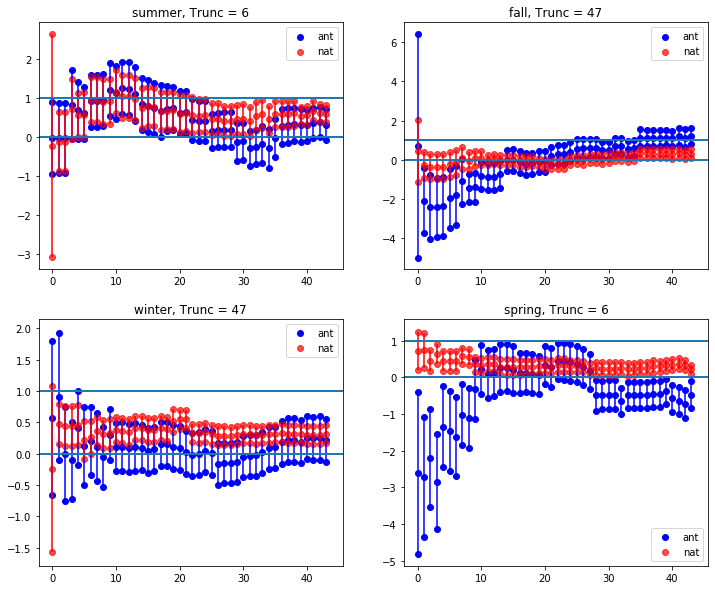

In [55]:
'''
MAIN PROGRAM

Create a seasonal plot of the regression coefficients using an array of trunctions.
The plots are saved in ~/figures/fingerprinting/scan_beta_est.
'''

fig,axs = plt.subplots(2,2, figsize=(12,10))#, sharex=True,sharey=True)

season_residuals = []
season_est_obs = []
season_obs = []

seasons = ['summer','fall','winter','spring']
for i,ax in enumerate(axs.flatten()):
    
    season = seasons[i]
        
    season_n = {'fall':3,'winter':6,'spring':9,'summer':12}[season]
    IDL.retall
    
    data_obs = get_obs_data('obs',season)
    
    all_ens_mean,noise_all,all_ens = get_mean_and_noise(season_n,'all','annual')
    nat_ens_mean,noise_nat,nat_ens = get_mean_and_noise(season_n,'nat','annual')
    
    data_noise_1 = np.concatenate((noise_all[:25],noise_nat[:25]))
    data_noise_2 = np.concatenate((noise_all[25:],noise_nat[25:]))
    
    data_scen = np.array([all_ens_mean,nat_ens_mean])
    
    trunc = np.array([i for i in range(3,48)])
    #trunc = 25
    
    B = ax.boxplot(data_obs)
    
    #a = min(data_obs)
    #b = max(data_obs)
    
    a=B['whiskers'][0].get_ydata()[1]
    b=B['whiskers'][1].get_ydata()[1]
        
    ax.clear()
    
    def scale(ary):
        mn = min(ary.flatten())
        mx = max(ary.flatten())
        
        new_ary = np.zeros(ary.shape)
        for i in range(ary.shape[0]):
            for j in range(ary.shape[1]):
                val = ary[i][j]
                new_ary[i][j] = (((b-a)*(val-mn))/(mx-mn))+a
                    
        return new_ary
        
    new_noise_1 = scale(data_noise_1)
    new_noise_2 = scale(data_noise_2)    
    
    IDL.data_obs = data_obs
    IDL.data_scen = data_scen
    IDL.data_noise_1 = new_noise_1
    IDL.data_noise_2 = new_noise_2
    IDL.trunc = trunc
    IDL.scan_beta_est = []
    IDL.scan_p_resid = []
    IDL.scan_resid_sumsq = []
    IDL.p_resid = []
    IDL.resid_sumsq = []
    IDL.noise_singval = []
    IDL.z_best = []

    IDL.run("gendetec, data_obs, data_scen, data_noise_1, beta_est, scan_resid_sumsq=scan_resid_sumsq, \
            data_noise_2=data_noise_2,transform=['1*0','1*0+1*1'], trunc=trunc, scan_beta_est=scan_beta_est,\
            scan_p_resid=scan_p_resid,noise_singval=noise_singval,z_best=z_best")

    #IDL.run("gendetec, data_obs, data_scen, data_noise_1, beta_est, \
    #        data_noise_2=data_noise_2,transform=['1*0','1*0+1*1'], trunc=trunc,\
    #        noise_singval=noise_singval,z_best=z_best")
    
    beta_est = IDL.beta_est
    scan_beta_est = IDL.scan_beta_est
    scan_p_resid = IDL.scan_p_resid
    scan_resid_sumsq = IDL.scan_resid_sumsq
    noise_singval = IDL.noise_singval
    z_best = IDL.z_best
    
    for i in range(len(scan_beta_est)):

        beta_est = scan_beta_est[i]
        
        best_1,low_1,up_1 = beta_est[0][0],beta_est[1][0],beta_est[2][0]
        best_2,low_2,up_2 = beta_est[0][1],beta_est[1][1],beta_est[2][1]

        ax.scatter([i for j in range(3)],[low_1,best_1,up_1],c='blue',label='ant' if i == 0 else '')
        ax.scatter([i for j in range(3)],[low_2,best_2,up_2],c='red',alpha=0.7,label='nat' if i == 0 else '')
        #ax.text(0.4,0.9,'p_resid = ' + str(p_resid[i]),transform=ax.transAxes)
        ax.vlines(i,low_1,up_1,colors=['blue'])
        ax.vlines(i,low_2,up_2,colors=['red'])
        ax.axhline(0,-0.5,1.5)
        ax.axhline(1,-0.5,1.5)
    #ax.set_xlim(-0.5,1.5)
    #ax.set_ylim(-10,5)
    
    
    ax.set_title(season + ', Trunc = ' + str(IDL.trunc))
    #ax.set_ylim(-0.0001, 0.00027)
    #if season != 'summer':
    #    ax.set_ylim(0,0.4)
    ax.legend()
    
    
    

In [ ]:
'''
MAIN PROGRAM

Create a seasonal plot of the regression coefficients using an array of trunctions.
The plots are saved in ~/figures/fingerprinting/scan_beta_est.
'''

fig,axs = plt.subplots(2,2, figsize=(12,10))#, sharex=True,sharey=True)

season_residuals = []
season_est_obs = []
season_obs = []

seasons = ['summer','fall','winter','spring']
for i,ax in enumerate(axs.flatten()):
    
    season = seasons[i]
        
    season_n = {'fall':3,'winter':6,'spring':9,'summer':12}[season]
    IDL.retall
    
    data_obs = get_obs_data('obs',season)
    
    all_ens_mean,noise_all,all_ens = get_mean_and_noise(season_n,'all','annual')
    nat_ens_mean,noise_nat,nat_ens = get_mean_and_noise(season_n,'nat','annual')
    
    data_noise_1 = np.concatenate((noise_all[:25],noise_nat[:25]))
    data_noise_2 = np.concatenate((noise_all[25:],noise_nat[25:]))
    
    data_scen = np.array([all_ens_mean,nat_ens_mean])
    
    trunc = np.array([i for i in range(3,48)])
    #trunc = 25
    
    B = ax.boxplot(data_obs)
    
    #a = min(data_obs)
    #b = max(data_obs)
    
    a=B['whiskers'][0].get_ydata()[1]
    b=B['whiskers'][1].get_ydata()[1]
        
    ax.clear()
    
    def scale(ary):
        mn = min(ary.flatten())
        mx = max(ary.flatten())
        
        new_ary = np.zeros(ary.shape)
        for i in range(ary.shape[0]):
            for j in range(ary.shape[1]):
                val = ary[i][j]
                new_ary[i][j] = (((b-a)*(val-mn))/(mx-mn))+a
                    
        return new_ary
        
    new_noise_1 = scale(data_noise_1)
    new_noise_2 = scale(data_noise_2)    
    
    data_noise_1 = new_noise_1
    data_noise_2 = new_noise_2
    
    
    IDL.data_obs = data_obs
    IDL.data_scen = data_scen
    IDL.data_noise_1 = data_noise_1
    IDL.data_noise_2 = data_noise_2
    IDL.trunc = trunc
    IDL.scan_beta_est = []
    IDL.scan_p_resid = []
    IDL.scan_resid_sumsq = []
    IDL.p_resid = []
    IDL.resid_sumsq = []
    IDL.noise_singval = []
    IDL.z_best = []

    IDL.run("gendetec, data_obs, data_scen, data_noise_1, beta_est, scan_resid_sumsq=scan_resid_sumsq, \
            data_noise_2=data_noise_2,transform=['1*0','1*0+1*1'], trunc=trunc, scan_beta_est=scan_beta_est,\
            scan_p_resid=scan_p_resid,noise_singval=noise_singval,z_best=z_best")

    #IDL.run("gendetec, data_obs, data_scen, data_noise_1, beta_est, \
    #        data_noise_2=data_noise_2,transform=['1*0','1*0+1*1'], trunc=trunc,\
    #        noise_singval=noise_singval,z_best=z_best")
    
    beta_est = IDL.beta_est
    scan_beta_est = IDL.scan_beta_est
    scan_p_resid = IDL.scan_p_resid
    scan_resid_sumsq = IDL.scan_resid_sumsq
    noise_singval = IDL.noise_singval
    z_best = IDL.z_best
    
    for i in range(len(scan_beta_est)):

        beta_est = scan_beta_est[i]
        
        best_1,low_1,up_1 = beta_est[0][0],beta_est[1][0],beta_est[2][0]
        best_2,low_2,up_2 = beta_est[0][1],beta_est[1][1],beta_est[2][1]

        ax.scatter([i for j in range(3)],[low_1,best_1,up_1],c='blue',label='ant' if i == 0 else '')
        ax.scatter([i for j in range(3)],[low_2,best_2,up_2],c='red',alpha=0.7,label='nat' if i == 0 else '')
        #ax.text(0.4,0.9,'p_resid = ' + str(p_resid[i]),transform=ax.transAxes)
        ax.vlines(i,low_1,up_1,colors=['blue'])
        ax.vlines(i,low_2,up_2,colors=['red'])
        ax.axhline(0,-0.5,1.5)
        ax.axhline(1,-0.5,1.5)
    #ax.set_xlim(-0.5,1.5)
    #ax.set_ylim(-10,5)
    
    
    ax.set_title(season + ', Trunc = ' + str(IDL.trunc))
    #ax.set_ylim(-0.0001, 0.00027)
    #if season != 'summer':
    #    ax.set_ylim(0,0.4)
    ax.legend()
    
    
    

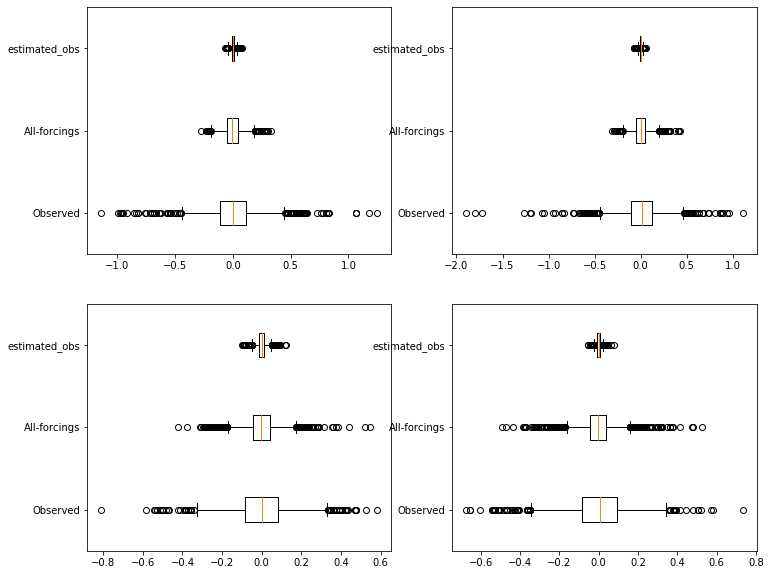

In [18]:
fig,axs = plt.subplots(2,2, figsize=(12,10))#, sharex=True,sharey=True)

seasons = ['summer','fall','winter','spring']
for i,ax in enumerate(axs.flatten()):
    
    season = seasons[i]
    season_n = {'fall':3,'winter':6,'spring':9,'summer':12}[season]
    
    data_obs = season_obs[i]
    data_est_obs = season_est_obs[i]
    data_all,noise_all = get_mean_and_noise(season_n,'all','annual')
    
    ax.boxplot([data_obs,data_all,data_est_obs],vert=False,labels=['Observed','All-forcings','estimated_obs'])
    #ax.hist(data_obs,bins,alpha=0.8,label='observed flow')
    #ax.hist(data_scen[0],bins,alpha=0.7,label='All-forcings runoff')
    
    #ax.set_xticks([0.0001*i for i in range(5)])
    #ax.text(0.0002,1.5,'difference of means:\n' + str(np.mean(data_obs) - np.mean(data_scen[0])))

    #ax.set_xlim(-0.0003,0.0003)
    #ax.text(0.00015,600,'difference of means:\n' + str(np.mean(data_obs) - np.mean(data_scen[0])))

    
    #if i == 0:
    #    ax.legend()
    


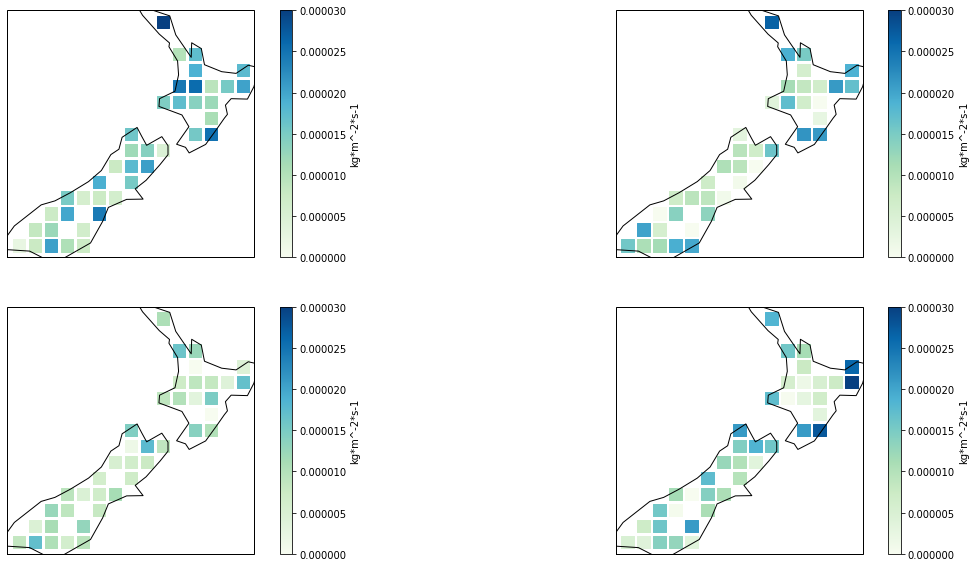

In [15]:
seasons = ['winter']#,'spring','summer''fall',]
scen = ['obs','nat','anth']
fig,axs = plt.subplots(2,2,subplot_kw={'projection': ccrs.PlateCarree()},figsize=(20,10))

obs_df = pd.read_csv('data/runoff/' + season + '_obs.csv')
obs_df = obs_df.set_index('date')


for s,ax in enumerate(axs.flatten()):
    
    residual = season_residuals[s].reshape(41,40)
    
    lons = [float(c.split(' ')[1]) for c in obs_df.columns]
    lats = [float(c.split(' ')[0]) for c in obs_df.columns]

    vals = []
    for cell in range(41):
        vals.append(np.mean(residual[cell]))

    im = ax.scatter(lons,lats,c=vals,cmap='GnBu',marker='s',s=150,vmin=0,vmax=0.00003) 
    fig.colorbar(im,ax=ax,label='kg*m^-2*s-1')
    ax.coastlines()
        
        